# Data preprocesing pipeline

In [163]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import scipy
from pprint import pprint
import seaborn as sns
import pathlib


### Paths

In [164]:
ARTIFACTS_PATH = pathlib.Path('artifacts')
DATASET_PATH = pathlib.Path('wine')

### Plots colors

In [165]:
colors = {'main1' : '#247ba0',
          'contrasting1' : '#fb3640',
          'main2' : '#b2ffa9',
          'contrasting2' : '#fee440',
          'black' : '#000000'}

## Data extraction

In [166]:
def load_data(path : pathlib.Path, pathToNames : pathlib.Path | None = None) -> pd.DataFrame:
    """Loads dataset from .csv file, optionaly assigns names to columns.

    Args:
        path (str): Path to dataset file.
        pathToNames (str | None, optional): Path to column names file. Defaults to None.

    Returns:
        pandas.DataFrame: Dataset objects.
    """
    data = pd.read_csv(path, header=None)
    if pathToNames:
        with open(pathToNames) as names:
            data.columns = [str(name).strip() for line in names.readlines() for name in line[:-1].split(',')] 
    return data

In [167]:
raw_data = load_data(DATASET_PATH.joinpath('data.csv'), DATASET_PATH.joinpath('column_names.csv'))
raw_data.sample(10)

,Target,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Prolin
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
159,3,13.48,1.67,2.64,22.5,89,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620
169,3,13.40,4.60,2.86,25.0,112,1.98,0.96,0.27,1.11,8.50,0.67,1.92,630
55,1,13.56,1.73,2.46,20.5,116,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120
145,3,13.16,3.57,2.15,21.0,102,1.50,0.55,0.43,1.30,4.00,0.60,1.68,830
11,1,14.12,1.48,2.32,16.8,95,2.20,2.43,0.26,1.57,5.00,1.17,2.82,1280
53,1,13.77,1.90,2.68,17.1,115,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375
35,1,13.48,1.81,2.41,20.5,100,2.70,2.98,0.26,1.86,5.10,1.04,3.47,920
157,3,12.45,3.03,2.64,27.0,97,1.90,0.58,0.63,1.14,7.50,0.67,1.73,880
172,3,14.16,2.51,2.48,20.0,91,1.68,0.70,0.44,1.24,9.70,0.62,1.71,660


## Data exploration and transformation

### Declaretion of dataframe with statistics

In [168]:
stats_index = [
    'Mean',
    'Min',
    'Max',
    'Standard deviation',
    'Range',
    'Median',
    'Q1',
    'Q3',
    'IQR',
    'UniqueValues',
    'BinsCount',
]

feature_cols = raw_data.columns.drop('Target').tolist()
target_col = 'Target'
target_values = sorted(raw_data[target_col].dropna().unique())
    
groups =  {'all': raw_data.drop('Target', axis=1)}
for val in target_values:
    groups[f'Target={val}'] = raw_data[raw_data[target_col] == val].drop('Target', axis=1)
    
stats_df = pd.DataFrame()

### Numbers of bins in histogram
calculatet based on [Freedman–Diaconis rule][def]
$$
NumBins = \frac{\text{maxValue} - \text{minValue}}{BinWidth}
$$

$$
BinWidth = 2 \cdot \text{IQR} \cdot \sqrt[3]{n}
$$

n - number of observations

[def]: https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule

In [169]:

def calculateBins(data_range : float, iqr : float, n : int) -> int:
    """Calculates numbers of bins in histogram based on Freedman-Diaconis rule.

    Args:
        data_range (float): Difference of maximum and minimum values.
        iqr (float): Interquartile range.
        n (int): Number of observations.

    Returns:
        int: Number of bins in nistogram
    """
    if n <= 1 or iqr == 0 or data_range == 0:
        bins = 1
    else:
        h = 2 * iqr * (n ** (-1/3))
        bins = int(np.ceil(data_range / h))
        
    return bins

### Generate latex table

In [ ]:
def generate_latex_table(path : pathlib.Path, df : pd.Series):
    df = df.drop(axis=0, labels=['BinsCount', 'UniqueValues'])
    df = df.iloc[df.index.str.len().argsort()[::-1]]
    df = df = df[df.columns[df.columns.str.len().argsort()]]
    with open(path, "w", encoding="utf-8") as f:
        f.write(
            df.to_latex(
                index=True,
                index_names=True,
                float_format="%.2f",
                bold_rows=False,
                escape=False
            )
    )

In [171]:
for group_name, df_group in groups.items():
    group_stats = pd.DataFrame(index=stats_index, columns=feature_cols, dtype=float)
    for column in feature_cols:
        data = df_group[column].dropna()
        
        group_stats.loc['UniqueValues', column] = data.nunique()
        group_stats.loc['Mean', column] = data.mean()
        group_stats.loc['Median', column] = data.median()
        group_stats.loc['Standard deviation', column] = data.std()
        
        min_value = data.min()
        max_value = data.max()
        data_range = max_value - min_value
        
        group_stats.loc['Min', column] = min_value
        group_stats.loc['Max', column] = max_value
        group_stats.loc['Range', column] = data_range
        
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        
        group_stats.loc['Q1', column] = q1
        group_stats.loc['Q3', column] = q3
        group_stats.loc['IQR', column] = iqr
        
        n = data.count()
        group_stats.loc['BinsCount', column] =  calculateBins(data_range, iqr, n)
    group_stats.columns = pd.MultiIndex.from_product([[group_name], group_stats.columns])
    stats_df = pd.concat([stats_df, group_stats], axis=1)
    


In [172]:
generate_latex_table(ARTIFACTS_PATH.joinpath("all_statistics.tex"), stats_df['all'])
stats_df['all']

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Prolin
Mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
Min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
Max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000
Standard deviation,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
Range,3.800000,5.060000,1.870000,19.400000,92.000000,2.900000,4.740000,0.530000,3.170000,11.720000,1.230000,2.730000,1402.000000
Median,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
Q1,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
Q3,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
IQR,1.315000,1.480000,0.347500,4.300000,19.000000,1.057500,1.670000,0.167500,0.700000,2.980000,0.337500,1.232500,484.500000
UniqueValues,126.000000,133.000000,79.000000,63.000000,53.000000,97.000000,132.000000,39.000000,101.000000,132.000000,78.000000,122.000000,121.000000


In [173]:
generate_latex_table(ARTIFACTS_PATH.joinpath('Target=1_statistics.tex'), stats_df['Target=1'])
stats_df['Target=1']

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Prolin
Mean,13.744746,2.010678,2.455593,17.037288,106.338983,2.840169,2.982373,0.290000,1.899322,5.528305,1.062034,3.157797,1115.711864
Min,12.850000,1.350000,2.040000,11.200000,89.000000,2.200000,2.190000,0.170000,1.250000,3.520000,0.820000,2.510000,680.000000
Max,14.830000,4.040000,3.220000,25.000000,132.000000,3.880000,3.930000,0.500000,2.960000,8.900000,1.280000,4.000000,1680.000000
Standard deviation,0.462125,0.688549,0.227166,2.546322,10.498949,0.338961,0.397494,0.070049,0.412109,1.238573,0.116483,0.357077,221.520767
Range,1.980000,2.690000,1.180000,13.800000,43.000000,1.680000,1.740000,0.330000,1.710000,5.380000,0.460000,1.490000,1000.000000
Median,13.750000,1.770000,2.440000,16.800000,104.000000,2.800000,2.980000,0.290000,1.870000,5.400000,1.070000,3.170000,1095.000000
Q1,13.400000,1.665000,2.295000,16.000000,98.000000,2.600000,2.680000,0.255000,1.640000,4.550000,0.995000,2.870000,987.500000
Q3,14.100000,1.935000,2.615000,18.700000,114.000000,3.000000,3.245000,0.320000,2.090000,6.225000,1.130000,3.420000,1280.000000
IQR,0.700000,0.270000,0.320000,2.700000,16.000000,0.400000,0.565000,0.065000,0.450000,1.675000,0.135000,0.550000,292.500000
UniqueValues,49.000000,45.000000,42.000000,40.000000,34.000000,34.000000,50.000000,23.000000,41.000000,53.000000,33.000000,45.000000,48.000000


In [174]:
generate_latex_table(ARTIFACTS_PATH.joinpath('Target=2_statistics.tex'), stats_df['Target=2'])
stats_df['Target=2']

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Prolin
Mean,12.278732,1.932676,2.244789,20.238028,94.549296,2.258873,2.080845,0.363662,1.630282,3.086620,1.056282,2.785352,519.507042
Min,11.030000,0.740000,1.360000,10.600000,70.000000,1.100000,0.570000,0.130000,0.410000,1.280000,0.690000,1.590000,278.000000
Max,13.860000,5.800000,3.230000,30.000000,162.000000,3.520000,5.080000,0.660000,3.580000,6.000000,1.710000,3.690000,985.000000
Standard deviation,0.537964,1.015569,0.315467,3.349770,16.753497,0.545361,0.705701,0.123961,0.602068,0.924929,0.202937,0.496573,157.211220
Range,2.830000,5.060000,1.870000,19.400000,92.000000,2.420000,4.510000,0.530000,3.170000,4.720000,1.020000,2.100000,707.000000
Median,12.290000,1.610000,2.240000,20.000000,88.000000,2.200000,2.030000,0.370000,1.610000,2.900000,1.040000,2.830000,495.000000
Q1,11.915000,1.270000,2.000000,18.000000,85.500000,1.895000,1.605000,0.270000,1.350000,2.535000,0.925000,2.440000,406.500000
Q3,12.515000,2.145000,2.420000,22.000000,99.500000,2.560000,2.475000,0.430000,1.885000,3.400000,1.205000,3.160000,625.000000
IQR,0.600000,0.875000,0.420000,4.000000,14.000000,0.665000,0.870000,0.160000,0.535000,0.865000,0.280000,0.720000,218.500000
UniqueValues,50.000000,61.000000,52.000000,34.000000,32.000000,51.000000,58.000000,33.000000,48.000000,49.000000,44.000000,56.000000,54.000000


In [175]:
generate_latex_table(ARTIFACTS_PATH.joinpath('Target=3_statistics.tex'), stats_df['Target=3'])
stats_df['Target=3']

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Prolin
Mean,13.153750,3.333750,2.437083,21.416667,99.312500,1.678750,0.781458,0.44750,1.153542,7.396250,0.682708,1.683542,629.895833
Min,12.200000,1.240000,2.100000,17.500000,80.000000,0.980000,0.340000,0.17000,0.550000,3.850000,0.480000,1.270000,415.000000
Max,14.340000,5.650000,2.860000,27.000000,123.000000,2.800000,1.570000,0.63000,2.700000,13.000000,0.960000,2.470000,880.000000
Standard deviation,0.530241,1.087906,0.184690,2.258161,10.890473,0.356971,0.293504,0.12414,0.408836,2.310942,0.114441,0.272111,115.097043
Range,2.140000,4.410000,0.760000,9.500000,43.000000,1.820000,1.230000,0.46000,2.150000,9.150000,0.480000,1.200000,465.000000
Median,13.165000,3.265000,2.380000,21.000000,97.000000,1.635000,0.685000,0.47000,1.105000,7.550000,0.665000,1.660000,627.500000
Q1,12.805000,2.587500,2.300000,20.000000,89.750000,1.407500,0.580000,0.39750,0.855000,5.437500,0.587500,1.510000,545.000000
Q3,13.505000,3.957500,2.602500,23.000000,106.000000,1.807500,0.920000,0.53000,1.350000,9.225000,0.752500,1.820000,695.000000
IQR,0.700000,1.370000,0.302500,3.000000,16.250000,0.400000,0.340000,0.13250,0.495000,3.787500,0.165000,0.310000,150.000000
UniqueValues,45.000000,47.000000,29.000000,18.000000,28.000000,34.000000,36.000000,25.00000,36.000000,44.000000,30.000000,36.000000,36.000000


In [176]:
print(f'NUMBER OF VALUES IN EACH COLUMN:\n{raw_data.count()}')
print(f'\nDataset shape: {raw_data.shape}')

NUMBER OF VALUES IN EACH COLUMN:
Target                          178
Alcohol                         178
Malic acid                      178
Ash                             178
Alcalinity of ash               178
Magnesium                       178
Total phenols                   178
Flavanoids                      178
Nonflavanoid phenols            178
Proanthocyanins                 178
Color intensity                 178
Hue                             178
OD280/OD315 of diluted wines    178
Prolin                          178
dtype: int64

Dataset shape: (178, 14)


In [177]:
print(f'DATA TYPES:\n{raw_data.dtypes}')

DATA TYPES:
Target                            int64
Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Prolin                            int64
dtype: object


### Target distribiution

Target
3    48
2    71
1    59
Name: count, dtype: int64


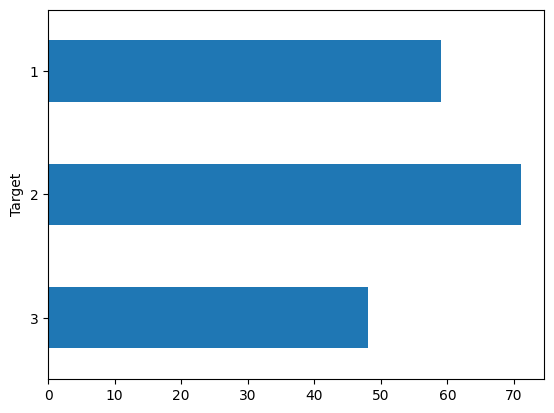

In [178]:
raw_data.Target.value_counts().sort_index(ascending=False).plot(kind='barh')
print(f'{raw_data.Target.value_counts().sort_index(ascending=False)}')

### Features distribiution

In [179]:
def plotDistibutions(groupName : str, groupDf : pd.DataFrame , columns : list[str]):
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        groupDf[column].plot(
            kind='hist',
            bins=int(stats_df[groupName][column].BinsCount),
            density=True,
            ax=axes[i],
            title=column,
            legend=False,
            color=colors['main1'],
            edgecolor='black'
        )
        
        groupDf[column].plot(
            kind='density',
            ax=axes[i],
            legend=False,
            color=colors['contrasting1']
        )
        
        

    # usuń puste subploty
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Distributions for {groupName}', fontsize=16)
    plt.tight_layout()
    plt.show()


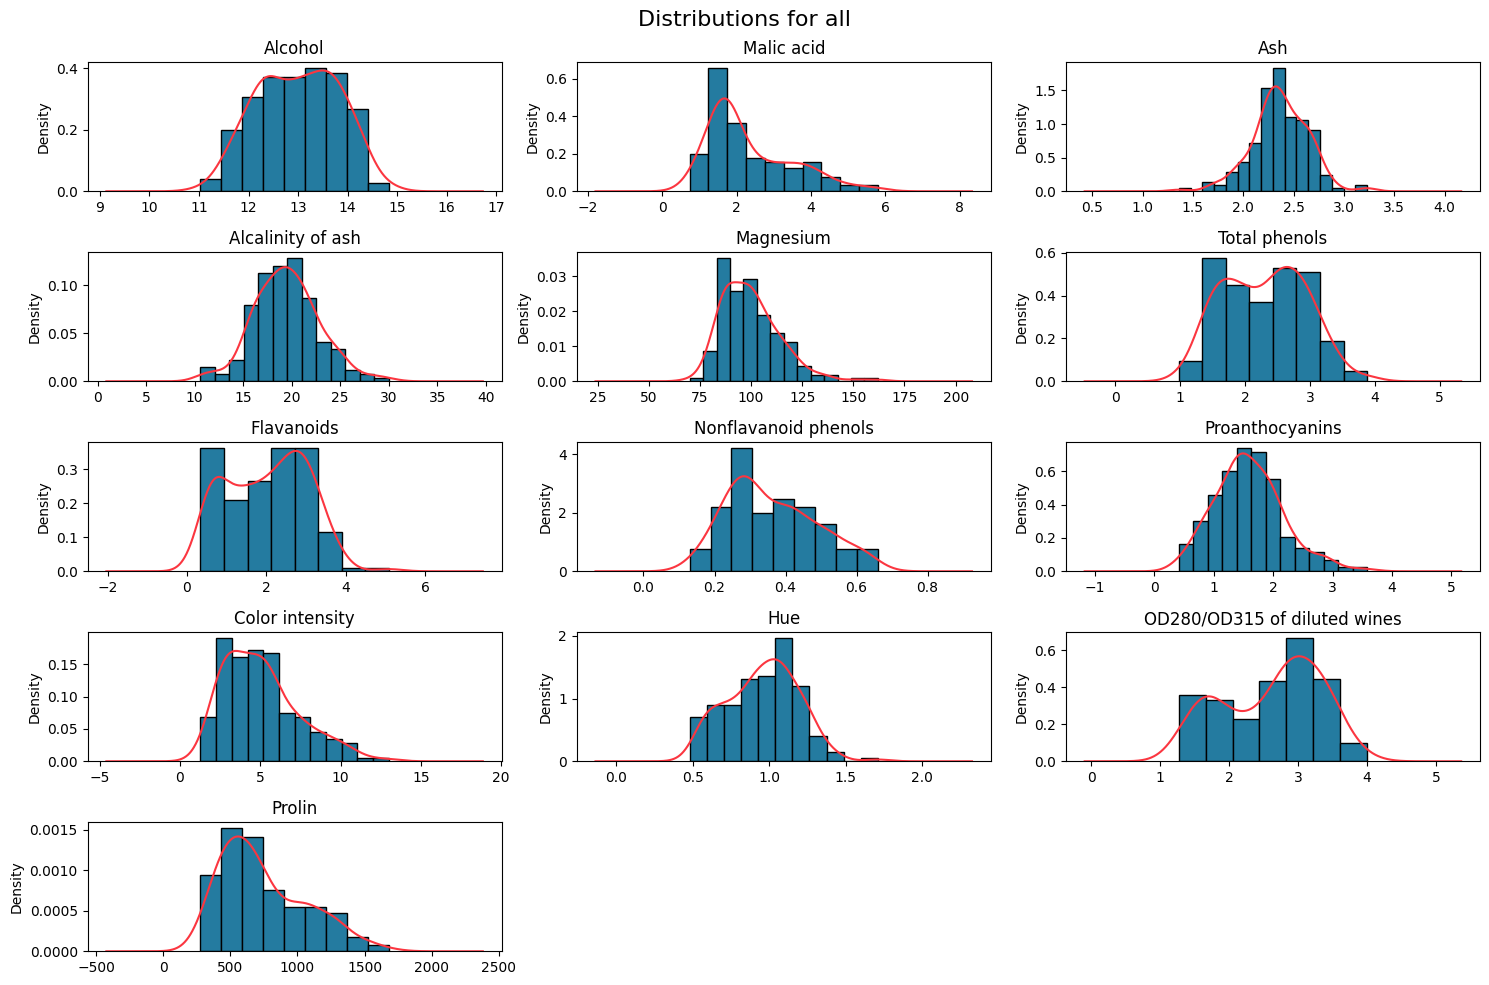

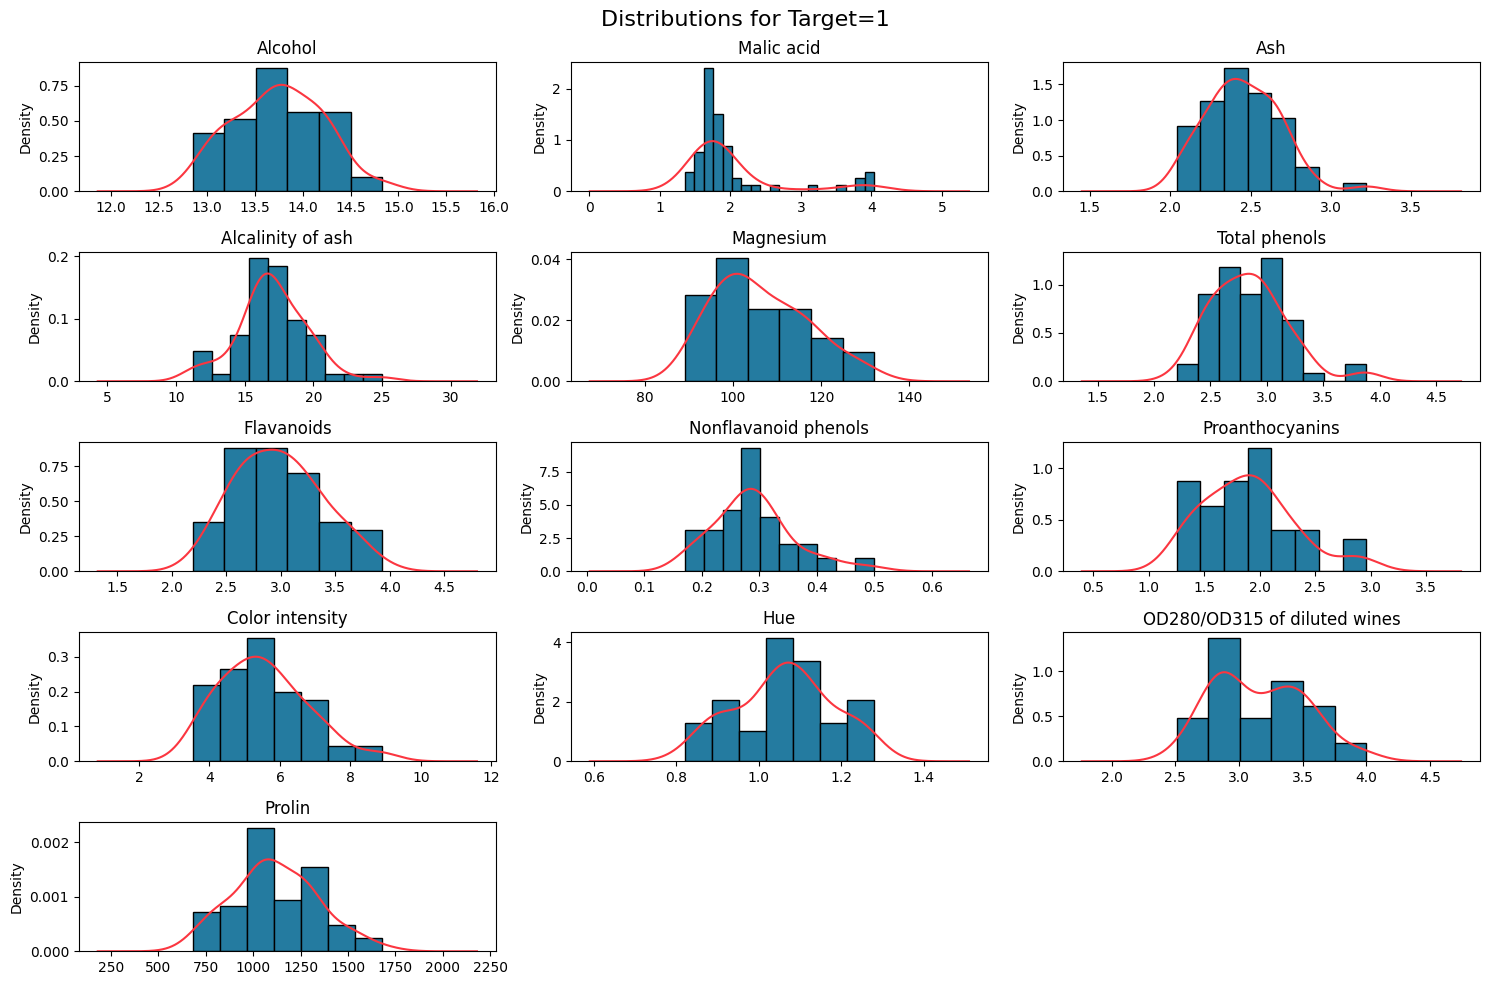

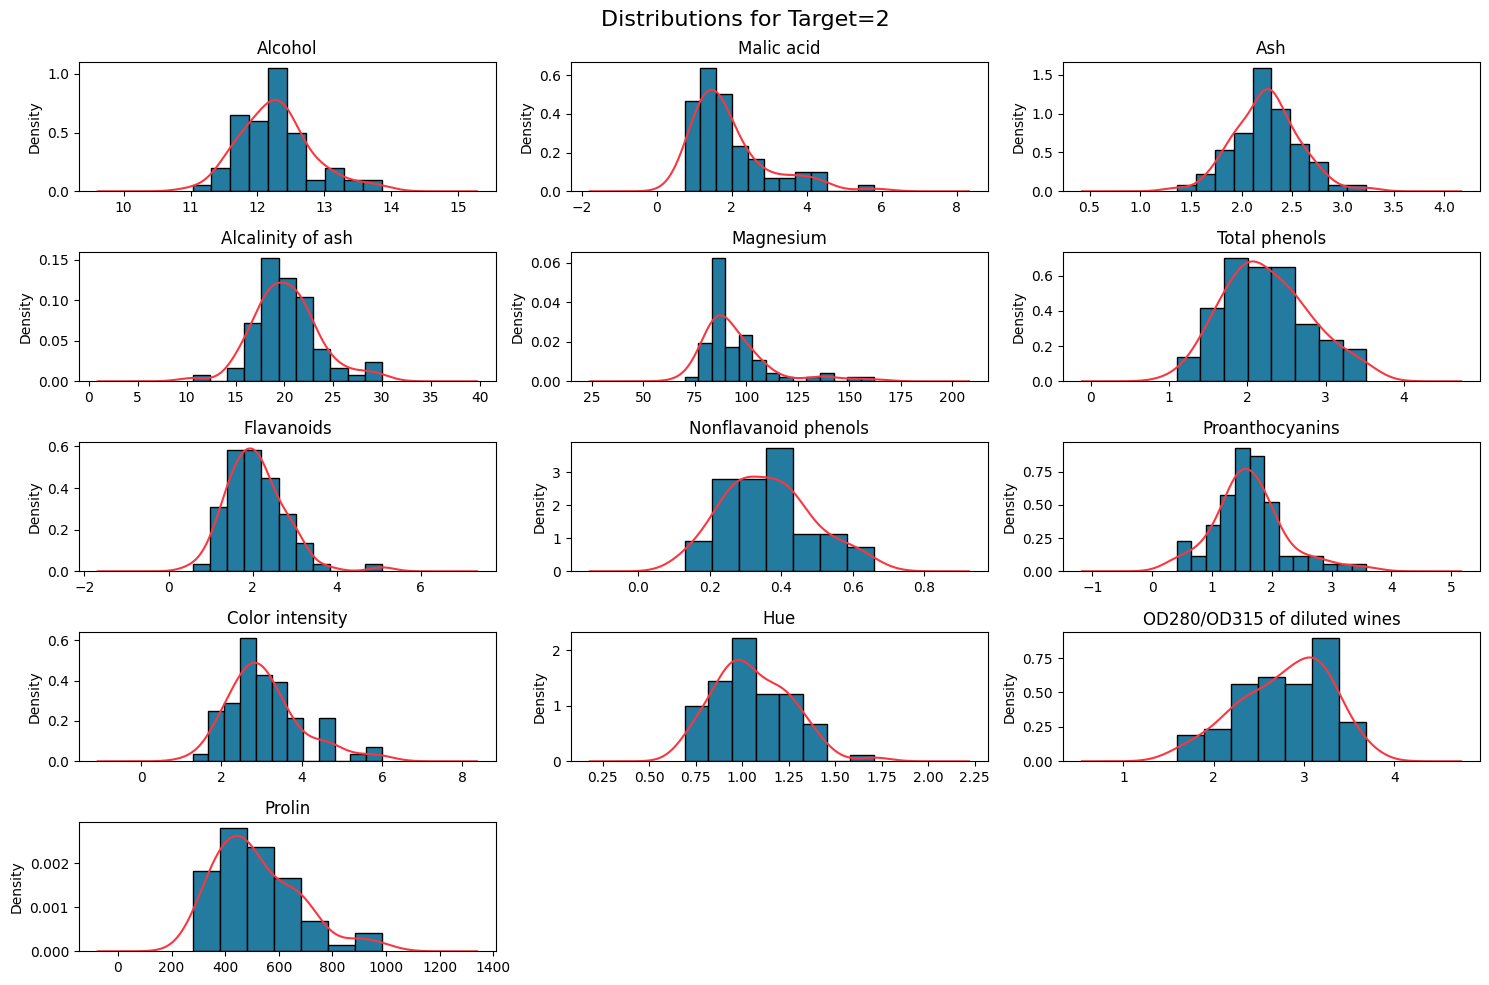

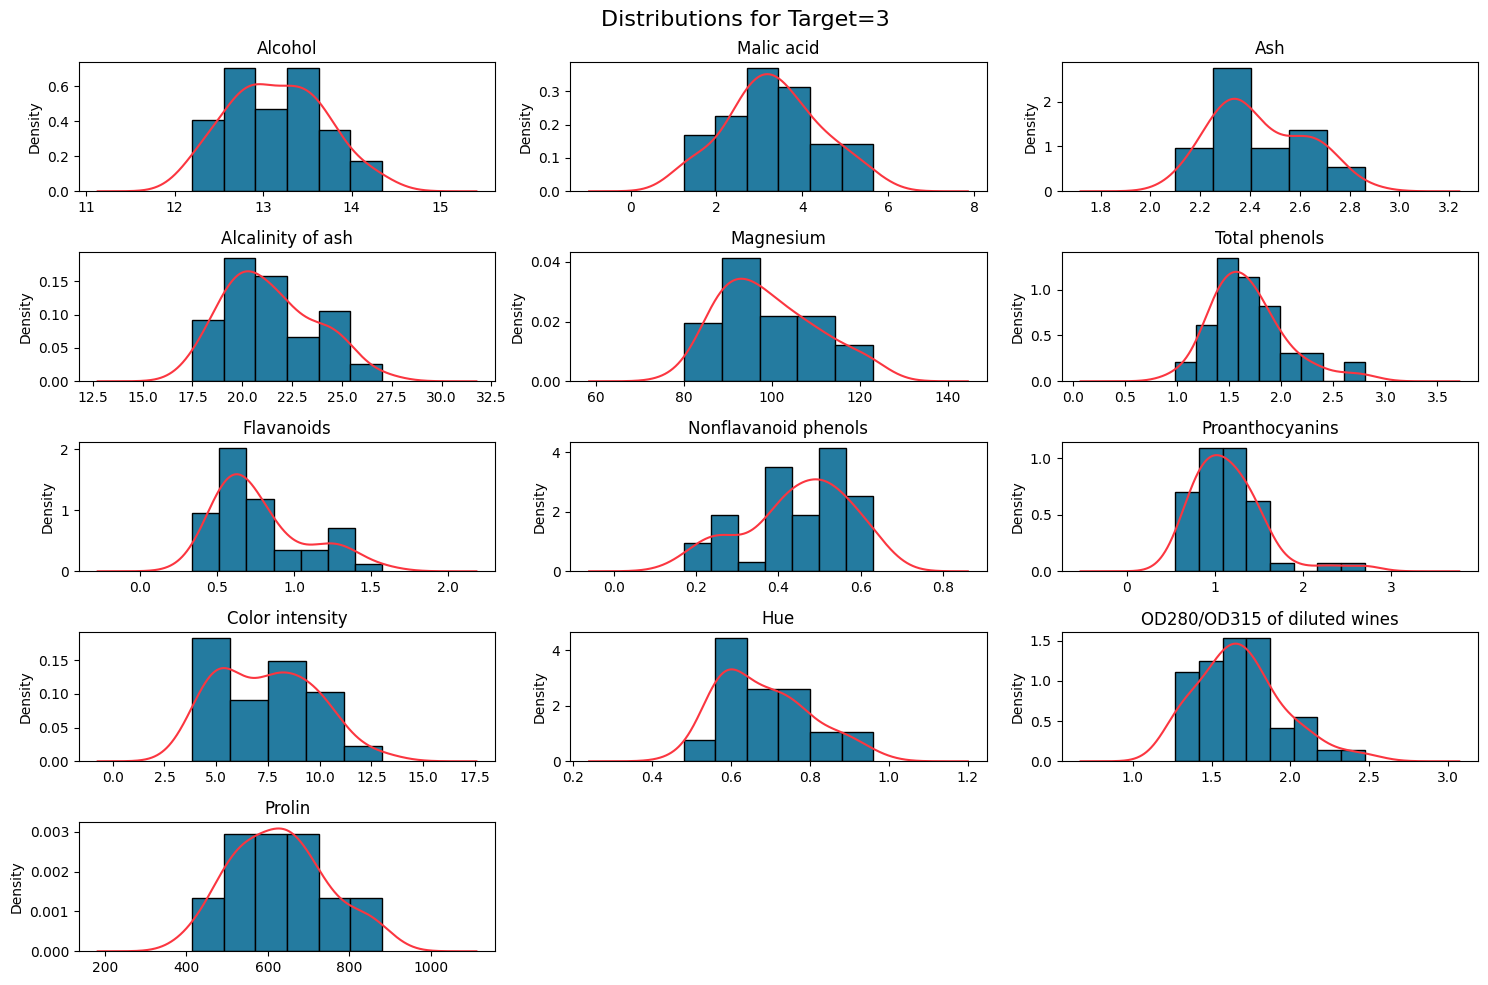

In [180]:
for name, df in groups.items():
    plotDistibutions(name, df, feature_cols)

### Features box plots

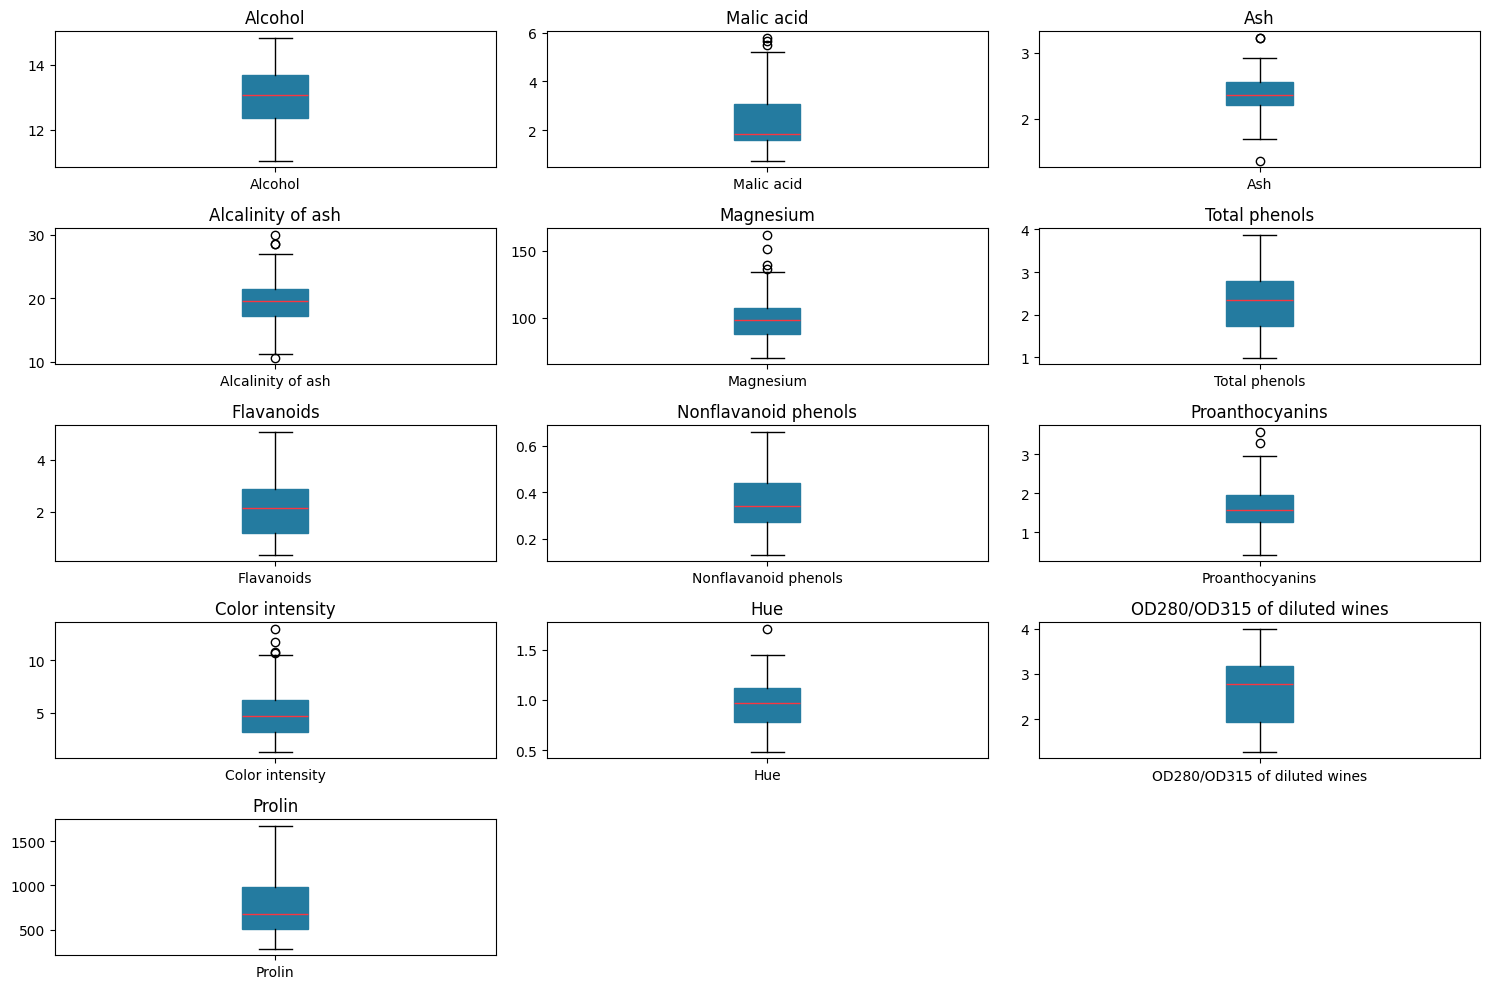

In [181]:

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(feature_cols):
    raw_data[column].plot(
        kind='box',
        ax=axes[i],
        title=column,
        patch_artist=True,
        color=dict(
            boxes=colors['main1'],
            whiskers=colors['black'],
            medians=colors['contrasting1'],
            caps=colors['black']
        )
    )
    
    
# usuń puste subploty
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Correlation matrix

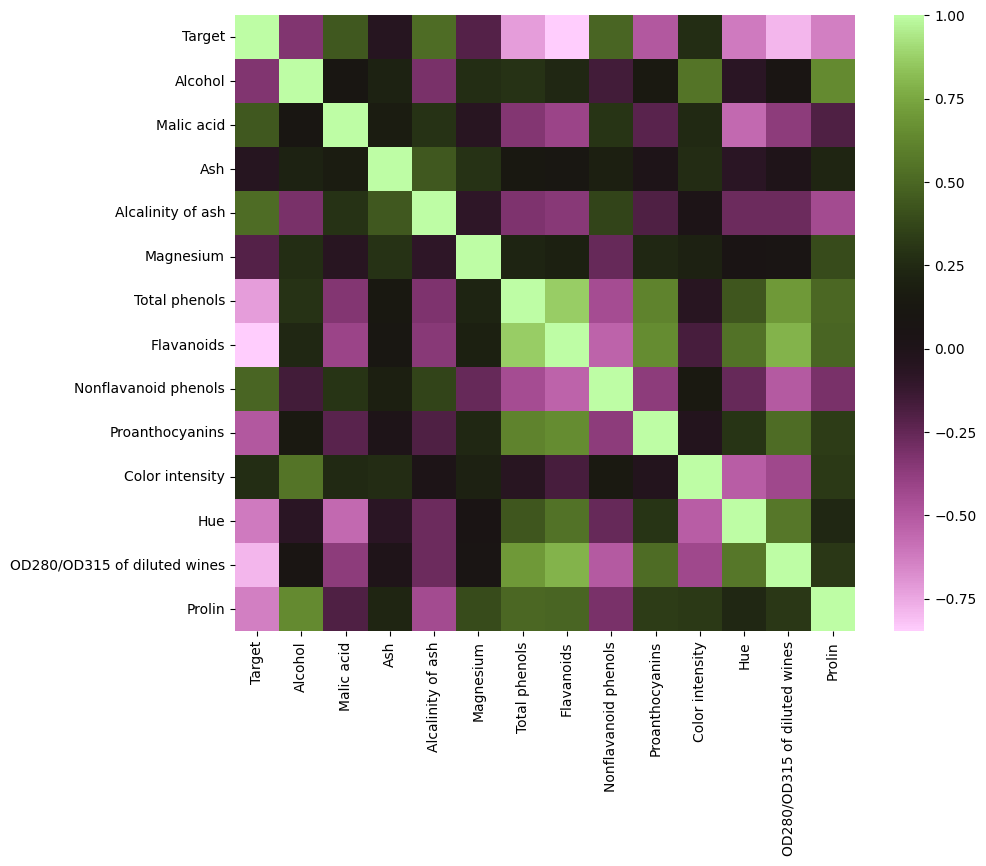

In [182]:
plt.figure(figsize=(10, 8))
sns.heatmap(raw_data.corr(), annot=False, cmap='vanimo')
plt.show()

In [183]:
raw_data.corr()['Target'].abs().sort_values(ascending=False)

Target                          1.000000
Flavanoids                      0.847498
OD280/OD315 of diluted wines    0.788230
Total phenols                   0.719163
Prolin                          0.633717
Hue                             0.617369
Alcalinity of ash               0.517859
Proanthocyanins                 0.499130
Nonflavanoid phenols            0.489109
Malic acid                      0.437776
Alcohol                         0.328222
Color intensity                 0.265668
Magnesium                       0.209179
Ash                             0.049643
Name: Target, dtype: float64

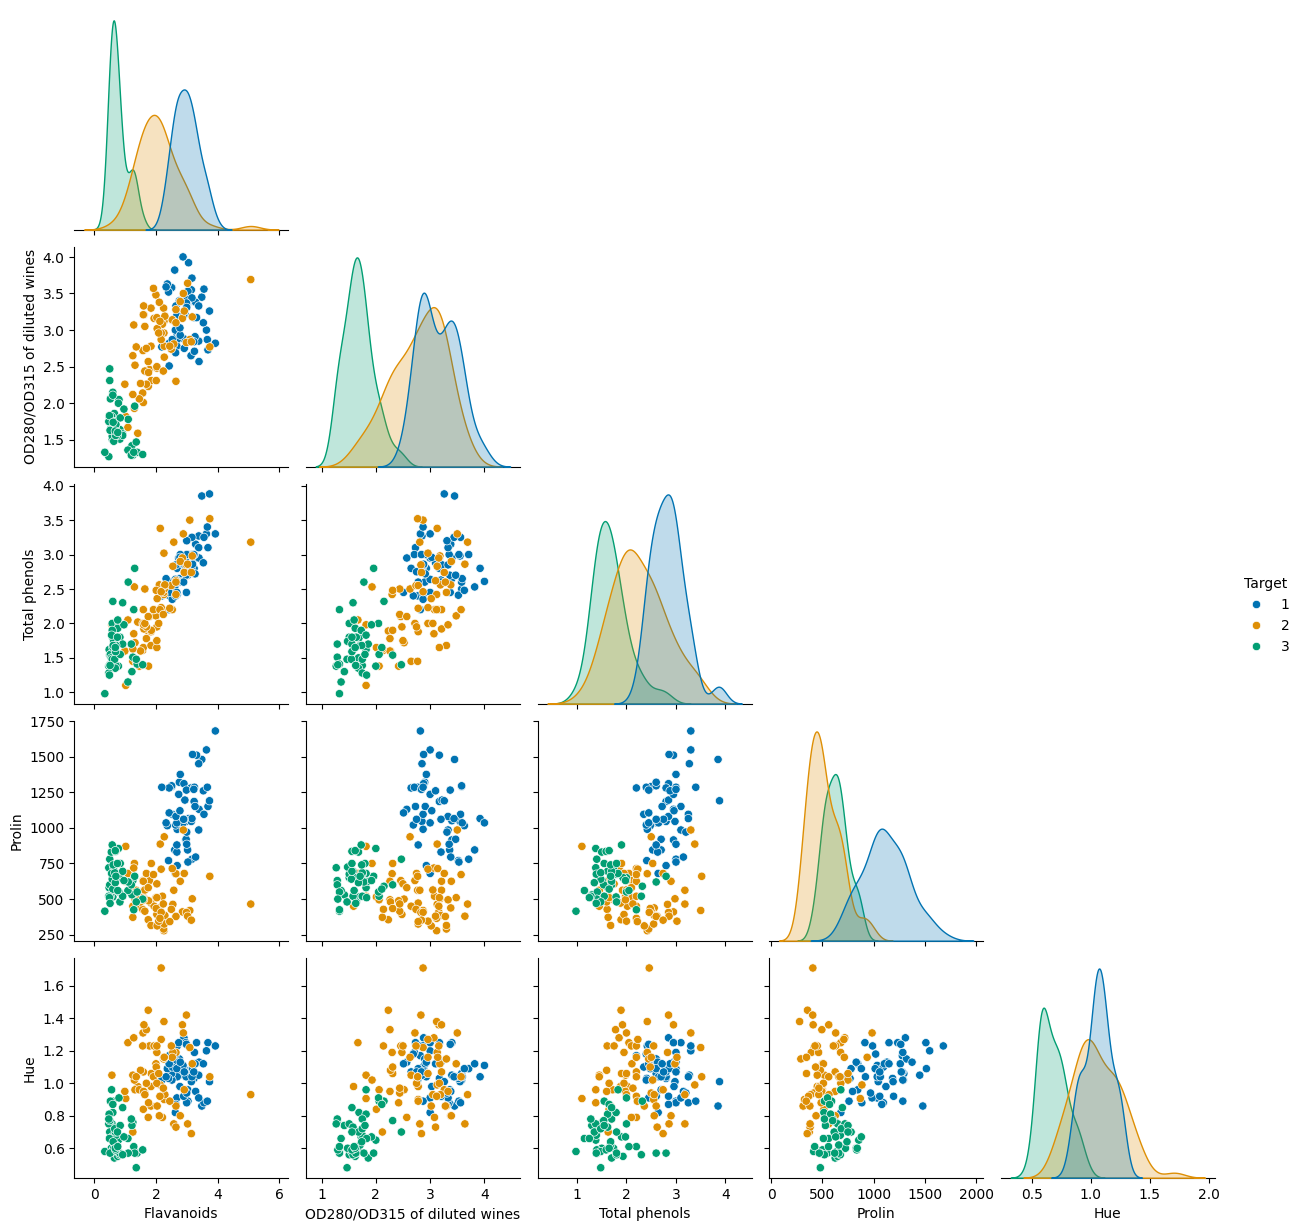

In [184]:
cols = ['Flavanoids', 'OD280/OD315 of diluted wines', 'Total phenols', 'Prolin', 'Hue','Target']
sns.pairplot(raw_data[cols], hue='Target', corner=True, palette= sns.color_palette('colorblind')[0:3])